**1. IMPORT LIBRARIES AND DATA**

1.1. Import libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

1.2. Read data

In [4]:
df=pd.read_csv('train.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


1.3. Initial data exploration

In [5]:
# Check data shape
df.shape

(8523, 12)

Descriptive statistics and value ranges of variables

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [7]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [8]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [9]:
df.describe(include=['object'])

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,8523,8523,8523,8523,6113,8523,8523
unique,1559,5,16,10,3,3,4
top,FDW13,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,10,5089,1232,935,2793,3350,5577


In [10]:
df['Item_Identifier'].value_counts()

,count
Item_Identifier,
FDW13,10
FDG33,10
FDX31,9
FDT07,9
NCY18,9
...,...
FDO33,1
FDK57,1
FDT35,1


In [11]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [12]:
df['Item_Type'].value_counts()

,count
Item_Type,
Fruits and Vegetables,1232
Snack Foods,1200
Household,910
Frozen Foods,856
Dairy,682
Canned,649
Baking Goods,648
Health and Hygiene,520
Soft Drinks,445


In [13]:
df['Outlet_Identifier'].value_counts()

,count
Outlet_Identifier,
OUT027,935
OUT013,932
OUT035,930
OUT049,930
OUT046,930
OUT045,929
OUT018,928
OUT017,926
OUT010,555


In [14]:
df['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
Small,2388
High,932


In [15]:
df['Outlet_Location_Type'].value_counts()

,count
Outlet_Location_Type,
Tier 3,3350
Tier 2,2785
Tier 1,2388


In [16]:
df['Outlet_Type'].value_counts()

,count
Outlet_Type,
Supermarket Type1,5577
Grocery Store,1083
Supermarket Type3,935
Supermarket Type2,928


Check correlation between variables

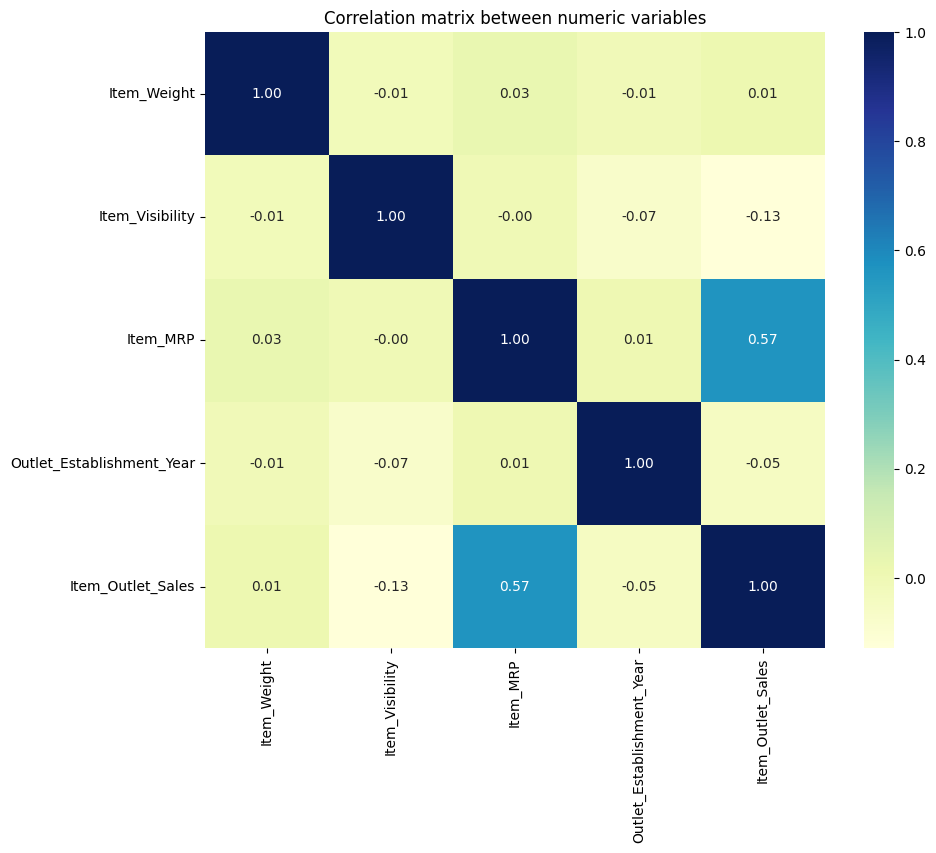

In [17]:
from matplotlib.colors import LinearSegmentedColormap
correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation matrix between numeric variables')
plt.show()

Lay the groundwork to handle unreasonable zero values in the Item_Visibility variable

In [18]:
# Filter rows where Item_Visibility equals 0 and select the necessary columns
visibility_zero = df[df['Item_Visibility'] == 0][['Item_Identifier', 'Item_Visibility', 'Item_Outlet_Sales']]

In [19]:
# Sort by descending sales to see best-selling items despite zero visibility
visibility_zero_sorted = visibility_zero.sort_values(by='Item_Outlet_Sales', ascending=False)

# Display results
print(visibility_zero_sorted.head(20))

     Item_Identifier  Item_Visibility  Item_Outlet_Sales
1450           FDZ20              0.0         11445.1020
4346           FDY55              0.0          9251.9568
472            FDU56              0.0          8114.7704
4676           DRE49              0.0          7741.9224
7562           FDY39              0.0          7717.9536
3255           FDI38              0.0          7247.2330
3400           FDE11              0.0          7033.5112
5494           FDD33              0.0          6970.9260
3863           NCZ18              0.0          6849.0846
1113           FDB21              0.0          6767.1912
2687           NCL53              0.0          6729.9064
5463           FDW55              0.0          6723.2484
4915           FDN34              0.0          6595.4148
844            FDV01              0.0          6515.5188
7149           FDT21              0.0          6474.2392
3979           FDA32              0.0          6471.5760
3033           FDY28           

In [20]:
# Count rows with zero visibility but sales > 0
print(f"Number of products with zero visibility but still having sales: {len(visibility_zero_sorted)}")

Number of products with zero visibility but still having sales: 526


**2. SPLIT TRAIN - TEST SET**

In [21]:
# Split feature variables (X) and target variable (y)
X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

In [22]:
# Split with a ratio of 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
# Check shape after splitting
X_train.shape

(5966, 11)

In [24]:
X_test.shape

(2557, 11)

In [25]:
X_train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,7.72,Regular,0.147904,Fruits and Vegetables,116.6466,OUT010,1998,NaN,Tier 3,Grocery Store
655,NCJ42,19.75,Low Fat,0.014301,Household,103.0332,OUT046,1997,Small,Tier 1,Supermarket Type1
2229,FDY47,NaN,Regular,0.054221,Breads,129.1310,OUT027,1985,Medium,Tier 3,Supermarket Type3
2537,FDN45,19.35,Low Fat,0.118342,Snack Foods,222.6088,OUT045,2002,NaN,Tier 2,Supermarket Type1
3528,FDY16,18.35,Regular,0.092150,Frozen Foods,184.8266,OUT013,1987,High,Tier 3,Supermarket Type1


In [26]:
y_train.head()

,Item_Outlet_Sales
1921,117.8466
655,1230.3984
2229,4933.5780
2537,1789.6704
3528,3872.9586


**3. DATA ANALYSIS AND CLEANING**

3.1. Copy training data

In [27]:
# Create a copy for analysis without affecting the original data
X_train_c = X_train.copy()

In [28]:
# Check shape
X_train_c.shape

(5966, 11)

3.2. Data statistics and inspection

In [29]:
# Descriptive statistics for numeric variables
X_train_c.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,4943.000000,5966.000000,5966.000000,5966.000000
mean,12.937193,0.065821,141.814242,1997.867248
std,4.630433,0.051093,62.627609,8.385023
min,4.555000,0.000000,31.290000,1985.000000
25%,8.895000,0.026982,94.144250,1987.000000
50%,12.650000,0.053923,143.879900,1999.000000
75%,17.000000,0.094350,186.621400,2004.000000
max,21.350000,0.328391,266.888400,2009.000000


In [30]:
# Overview of the structure and current status of the training dataset
X_train_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5966 entries, 1921 to 7270
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5966 non-null   object 
 1   Item_Weight                4943 non-null   float64
 2   Item_Fat_Content           5966 non-null   object 
 3   Item_Visibility            5966 non-null   float64
 4   Item_Type                  5966 non-null   object 
 5   Item_MRP                   5966 non-null   float64
 6   Outlet_Identifier          5966 non-null   object 
 7   Outlet_Establishment_Year  5966 non-null   int64  
 8   Outlet_Size                4276 non-null   object 
 9   Outlet_Location_Type       5966 non-null   object 
 10  Outlet_Type                5966 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 559.3+ KB


In [31]:
# Check missing values
X_train_c.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1023
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,1690
Outlet_Location_Type,0


In [32]:
# Check duplicate values
X_train_c.duplicated().sum()

np.int64(0)

**4. NUMERIC VARIABLE ANALYSIS**

In [33]:
# Separate numeric columns from object columns
num_data = X_train_c.select_dtypes(exclude='object')
num_data.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
1921,7.72,0.147904,116.6466,1998
655,19.75,0.014301,103.0332,1997
2229,NaN,0.054221,129.1310,1985
2537,19.35,0.118342,222.6088,2002
3528,18.35,0.092150,184.8266,1987


In [34]:
# Descriptive statistics for numeric variables
num_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,4943.000000,5966.000000,5966.000000,5966.000000
mean,12.937193,0.065821,141.814242,1997.867248
std,4.630433,0.051093,62.627609,8.385023
min,4.555000,0.000000,31.290000,1985.000000
25%,8.895000,0.026982,94.144250,1987.000000
50%,12.650000,0.053923,143.879900,1999.000000
75%,17.000000,0.094350,186.621400,2004.000000
max,21.350000,0.328391,266.888400,2009.000000


In [35]:
# Check missing values of numeric variables
num_data.isnull().sum()

,0
Item_Weight,1023
Item_Visibility,0
Item_MRP,0
Outlet_Establishment_Year,0


In [36]:
# Automate and reuse the process of visualizing distribution and outliers
def visualize_numeric_features(data_frame, col_name):
  fig, ax = plt.subplots(1, 2, figsize=(12, 5))
  sns.histplot(data = data_frame, x = col_name, ax=ax[0]);
  sns.boxplot(data = data_frame, y = col_name, ax=ax[1]);

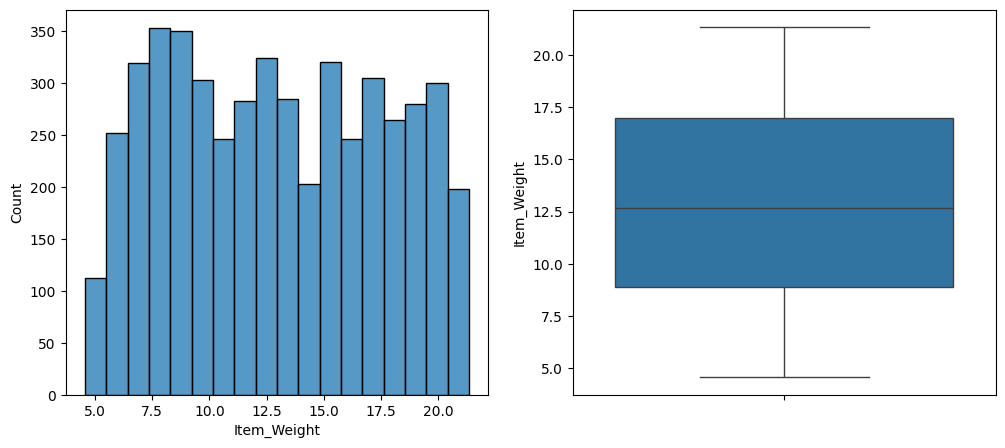

In [37]:
# Check distribution and outlier visualization for the 'Item_Weight' variable
visualize_numeric_features(X_train_c, 'Item_Weight')

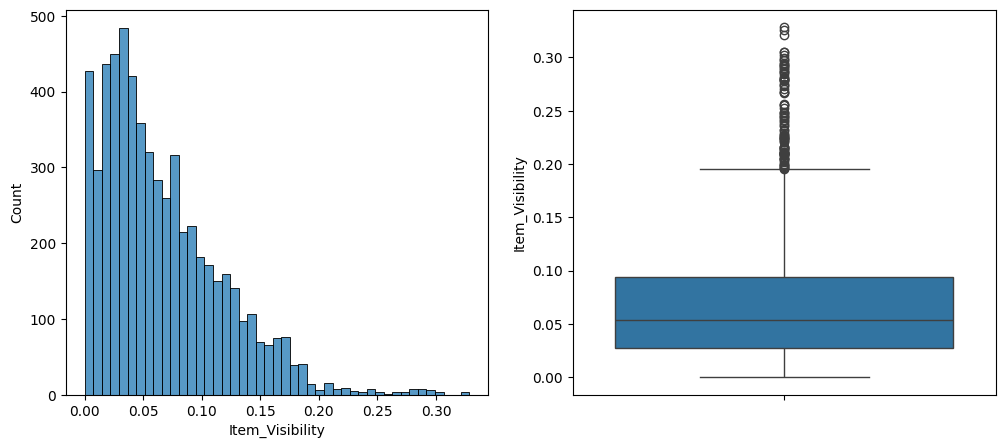

In [38]:
# Check distribution and outlier visualization for the 'Item_Visibility' variable
visualize_numeric_features(X_train_c, 'Item_Visibility')

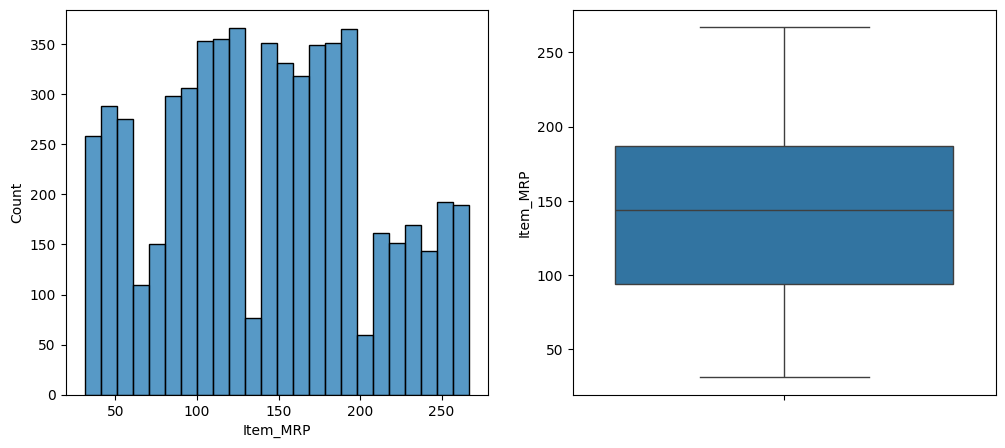

In [39]:
# Check distribution and outlier visualization for the 'Item_MRP' variable
visualize_numeric_features(X_train_c, 'Item_MRP')

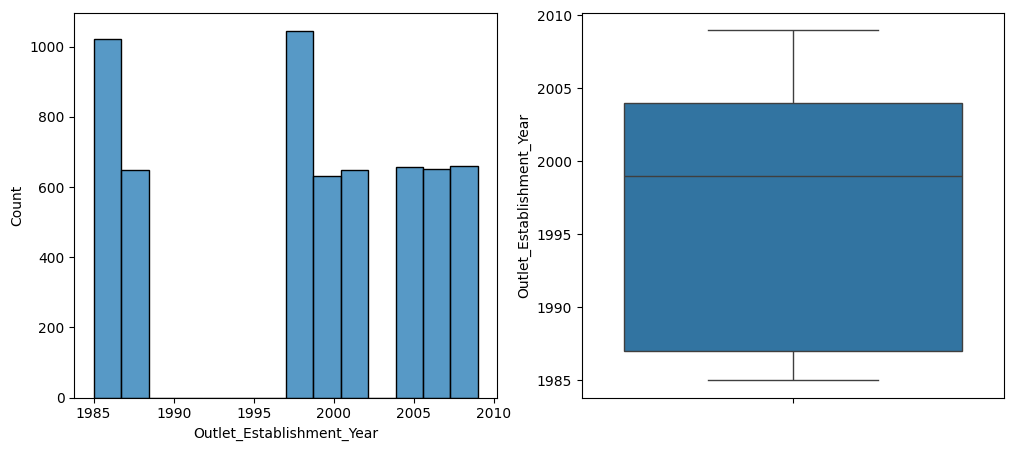

In [40]:
# Check distribution and outlier visualization for the 'Outlet_Establishment_Year' variable
visualize_numeric_features(X_train_c, 'Outlet_Establishment_Year')

<Axes: xlabel='Outlet_Establishment_Year', ylabel='count'>

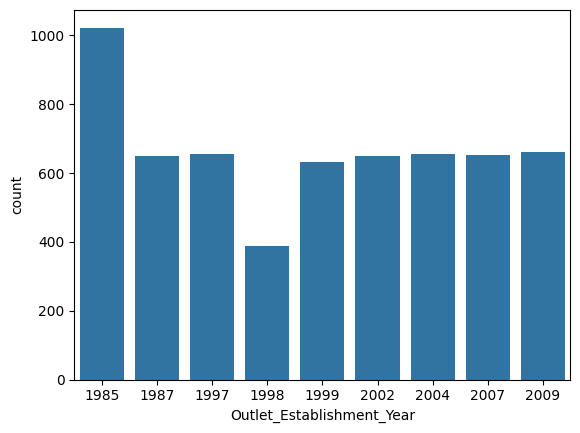

In [41]:
# Analyze the frequency distribution of the 'Outlet_Establishment_Year' variable
sns.countplot(data = X_train_c, x = 'Outlet_Establishment_Year')

**5. CATEGORICAL VARIABLE ANALYSIS**

In [42]:
# Extract categorical variables
cat_features = X_train_c.select_dtypes(include='object')
cat_features.head()

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,Regular,Fruits and Vegetables,OUT010,NaN,Tier 3,Grocery Store
655,NCJ42,Low Fat,Household,OUT046,Small,Tier 1,Supermarket Type1
2229,FDY47,Regular,Breads,OUT027,Medium,Tier 3,Supermarket Type3
2537,FDN45,Low Fat,Snack Foods,OUT045,NaN,Tier 2,Supermarket Type1
3528,FDY16,Regular,Frozen Foods,OUT013,High,Tier 3,Supermarket Type1


In [43]:
# Descriptive statistics for categorical variables in the dataset
cat_features.describe()

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,5966,5966,5966,5966,4276,5966,5966
unique,1543,5,16,10,3,3,4
top,FDF52,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,9,3535,905,668,1960,2367,3893


In [44]:
# Check missing values of categorical variables
cat_features.isnull().sum()

,0
Item_Identifier,0
Item_Fat_Content,0
Item_Type,0
Outlet_Identifier,0
Outlet_Size,1690
Outlet_Location_Type,0
Outlet_Type,0


In [45]:
# Count occurrences of each value in the 'Item_Identifier' variable
cat_features['Item_Identifier'].value_counts()

,count
Item_Identifier,
FDF52,9
NCI54,9
FDN56,8
DRE49,8
FDV60,8
...,...
FDR16,1
FDY19,1
FDV27,1


In [46]:
# Count occurrences of each value in the 'Item_Fat_Content' variable
cat_features['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,3535
Regular,2027
LF,243
low fat,82
reg,79


In [47]:
# Count occurrences of each value in the 'Item_Type' variable
cat_features['Item_Type'].value_counts()

,count
Item_Type,
Fruits and Vegetables,905
Snack Foods,835
Household,648
Frozen Foods,591
Dairy,474
Canned,450
Baking Goods,438
Health and Hygiene,365
Soft Drinks,305


In [48]:
# Count occurrences of each value in the 'Outlet_Identifier' variable
cat_features['Outlet_Identifier'].value_counts()

,count
Outlet_Identifier,
OUT027,668
OUT018,661
OUT035,656
OUT046,656
OUT017,652
OUT013,649
OUT045,649
OUT049,631
OUT010,389


In [49]:
# Count occurrences of each value in the 'Outlet_Size' variable
cat_features['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,1960
Small,1667
High,649


In [50]:
# Count occurrences of each value in the 'Outlet_Location_Type' variable
cat_features['Outlet_Location_Type'].value_counts()

,count
Outlet_Location_Type,
Tier 3,2367
Tier 2,1957
Tier 1,1642


In [51]:
# Count occurrences of each value in the 'Outlet_Type' variable
cat_features['Outlet_Type'].value_counts()

,count
Outlet_Type,
Supermarket Type1,3893
Grocery Store,744
Supermarket Type3,668
Supermarket Type2,661


**6. FEATURE ENGINEERING**

In [52]:
# Extract the first 2 characters of the product code (Item_Identifier)
X_train_c['Item_Identifier'].str[:2].value_counts()

,count
Item_Identifier,
FD,4269
NC,1137
DR,560


6.1. Create a general item type variable

In [53]:
# Convert data from technical encoded form to a practically meaningful form
def create_item_type_column(data_frame):
  data_frame['Item_Type'] = data_frame['Item_Identifier'].str[:2]
  data_frame['Item_Type'] = data_frame['Item_Type'].map({
      'FD':'Food', 'NC':'Non-Consumable', 'DR':'Drinks'
  })
  return data_frame

In [54]:
X_train_c = create_item_type_column(X_train_c)
X_train_c.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,7.72,Regular,0.147904,Food,116.6466,OUT010,1998,NaN,Tier 3,Grocery Store
655,NCJ42,19.75,Low Fat,0.014301,Non-Consumable,103.0332,OUT046,1997,Small,Tier 1,Supermarket Type1
2229,FDY47,NaN,Regular,0.054221,Food,129.1310,OUT027,1985,Medium,Tier 3,Supermarket Type3
2537,FDN45,19.35,Low Fat,0.118342,Food,222.6088,OUT045,2002,NaN,Tier 2,Supermarket Type1
3528,FDY16,18.35,Regular,0.092150,Food,184.8266,OUT013,1987,High,Tier 3,Supermarket Type1


6.2. Handle missing values of the 'Item_Weight' variable

In [55]:
X_train_c.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1023
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,1690
Outlet_Location_Type,0


In [56]:
# Test hypothesis: same product code has the same weight
X_train_c[['Item_Identifier', 'Item_Weight']].drop_duplicates().sort_values('Item_Identifier')

,Item_Identifier,Item_Weight
1245,DRA12,11.60
4900,DRA24,19.35
6057,DRA59,NaN
1876,DRA59,8.27
3733,DRB01,NaN
...,...,...
411,NCZ42,10.50
2084,NCZ53,NaN
6879,NCZ53,9.60
7926,NCZ54,14.65


In [57]:
X_train_c[X_train_c['Item_Identifier'] == 'DRA59'][['Item_Identifier', 'Item_Weight']].sort_values(by='Item_Weight')

,Item_Identifier,Item_Weight
1876,DRA59,8.27
5609,DRA59,8.27
3927,DRA59,8.27
3962,DRA59,8.27
6057,DRA59,NaN
6179,DRA59,NaN


In [58]:
# Check by product group
X_train_c[['Item_Type', 'Item_Weight']].drop_duplicates().sort_values(by=['Item_Type'])

,Item_Type,Item_Weight
2796,Drinks,5.730
998,Drinks,20.250
670,Drinks,8.395
6091,Drinks,13.500
3438,Drinks,13.850
...,...,...
6624,Non-Consumable,12.600
6191,Non-Consumable,8.880
1911,Non-Consumable,19.850
135,Non-Consumable,7.235


Fill in missing values for the Item_Weight variable


Step 1: Use the mapping between product code (Item_Identifier) and weight (Item_Weight) to fill in missing values.


Step 2: For completely new products (not present in the training set), use the median weight by product group to fill in missing values.

In [59]:
ITEM_ID_WEIGHT_PIVOT = X_train_c.pivot_table(values='Item_Weight', index='Item_Identifier').reset_index()
ITEM_ID_WEIGHT_MAPPING = dict(zip(ITEM_ID_WEIGHT_PIVOT['Item_Identifier'], ITEM_ID_WEIGHT_PIVOT['Item_Weight']))
list(ITEM_ID_WEIGHT_MAPPING.items())[:10]

[('DRA12', 11.6),
 ('DRA24', 19.35),
 ('DRA59', 8.27),
 ('DRB01', 7.39),
 ('DRB13', 6.115),
 ('DRB24', 8.785),
 ('DRB25', 12.300000000000002),
 ('DRB48', 16.75),
 ('DRC01', 5.92),
 ('DRC12', 17.85)]

In [60]:
ITEM_TYPE_WEIGHT_PIVOT = X_train_c.pivot_table(values='Item_Weight', index='Item_Type',
                                               aggfunc='median').reset_index()
ITEM_TYPE_WEIGHT_MAPPING = dict(zip(ITEM_TYPE_WEIGHT_PIVOT['Item_Type'], ITEM_TYPE_WEIGHT_PIVOT['Item_Weight']))
ITEM_TYPE_WEIGHT_MAPPING.items()

dict_items([('Drinks', 11.8), ('Food', 12.8), ('Non-Consumable', 13.05)])

In [61]:
def impute_item_weight(data_frame):
  data_frame.loc[:,'Item_Weight'] = data_frame.loc[:,'Item_Weight'].fillna(data_frame.loc[:,'Item_Identifier'].map(ITEM_ID_WEIGHT_MAPPING))
  data_frame.loc[:,'Item_Weight'] = data_frame.loc[:,'Item_Weight'].fillna(data_frame.loc[:,'Item_Type'].map(ITEM_TYPE_WEIGHT_MAPPING))
  return data_frame

In [62]:
# Fill in missing values for the 'Item_Weight' variable on the copied training dataset
X_train_c = impute_item_weight(X_train_c)

In [63]:
# Check remaining missing values
X_train_c.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,1690
Outlet_Location_Type,0


6.3. Handle missing values of the 'Outlet_Size' variable

In [64]:
# Check how many times each 'Outlet_Size' appears for each 'Outlet_Type'?
X_train_c.groupby(by=['Outlet_Type', 'Outlet_Size']).size()

Outlet_Type        Outlet_Size
Grocery Store      Small           355
Supermarket Type1  High            649
                   Medium          631
                   Small          1312
Supermarket Type2  Medium          661
Supermarket Type3  Medium          668
dtype: int64

In [65]:
# Find the most frequent Outlet_Size value within each Outlet_Type group
from scipy.stats import mode
OUTLET_TYPE_SIZE_PIVOT = X_train_c.pivot_table(values='Outlet_Size', index='Outlet_Type',
                                               aggfunc=(lambda x : x.mode()[0])).reset_index()
OUTLET_TYPE_SIZE_MAPPING = dict(zip(OUTLET_TYPE_SIZE_PIVOT['Outlet_Type'], OUTLET_TYPE_SIZE_PIVOT['Outlet_Size']))
OUTLET_TYPE_SIZE_MAPPING.items()

dict_items([('Grocery Store', 'Small'), ('Supermarket Type1', 'Small'), ('Supermarket Type2', 'Medium'), ('Supermarket Type3', 'Medium')])

In [66]:
def impute_outlet_size(data_frame):
  data_frame.loc[:,'Outlet_Size'] = data_frame.loc[:,'Outlet_Size'].fillna(data_frame.loc[:,'Outlet_Type'].map(OUTLET_TYPE_SIZE_MAPPING))
  return data_frame

In [67]:
# Fill in missing values for the Outlet_Type variable on the copied training dataset
X_train_c = impute_outlet_size(X_train_c)

In [68]:
# Check remaining missing values
X_train_c.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


6.3. Handle consistency and validity of the 'Item_Fat_Content' variable

In [69]:
# List and count occurrences of unique values
X_train_c['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,3535
Regular,2027
LF,243
low fat,82
reg,79


In [70]:
# Group similar values under the same label
def standardize_item_fat_content(data_frame):
  data_frame['Item_Fat_Content'] = data_frame['Item_Fat_Content'].replace({
      'LF':'Low Fat', 'low fat':'Low Fat', 'reg':'Regular'
  })
  return data_frame

In [71]:
X_train_c = standardize_item_fat_content(X_train_c)
X_train_c['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,3860
Regular,2106


6.4. Adjust (correct) fat content information for non-consumable products

In [72]:
# Check how many times each 'Item_Fat_Content' appears for each 'Item_Type'?
X_train_c.groupby(by=['Item_Type', 'Item_Fat_Content']).size()

Item_Type       Item_Fat_Content
Drinks          Low Fat              517
                Regular               43
Food            Low Fat             2206
                Regular             2063
Non-Consumable  Low Fat             1137
dtype: int64

In [73]:
# Check separately the 'Non-Consumable' rows
X_train_c.loc[X_train_c['Item_Type'] == 'Non-Consumable', 'Item_Fat_Content']

,Item_Fat_Content
655,Low Fat
4423,Low Fat
907,Low Fat
7021,Low Fat
6074,Low Fat
...,...
8322,Low Fat
466,Low Fat
6265,Low Fat
5390,Low Fat


In [74]:
# Assign the non-edible label 'Non_Edible' to 'Non-Consumable' rows that were assigned an 'Item_Fat_Content' value
def correct_item_fat_content(data_frame):
  data_frame.loc[data_frame['Item_Type'] == 'Non-Consumable', 'Item_Fat_Content'] = 'Non_Edible'
  return data_frame

In [75]:
X_train_c = correct_item_fat_content(X_train_c)
X_train_c.groupby(by=['Item_Type', 'Item_Fat_Content']).size()

Item_Type       Item_Fat_Content
Drinks          Low Fat              517
                Regular               43
Food            Low Fat             2206
                Regular             2063
Non-Consumable  Non_Edible          1137
dtype: int64

In [76]:
# View overview information: data types and number of non-null values
X_train_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5966 entries, 1921 to 7270
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5966 non-null   object 
 1   Item_Weight                5966 non-null   float64
 2   Item_Fat_Content           5966 non-null   object 
 3   Item_Visibility            5966 non-null   float64
 4   Item_Type                  5966 non-null   object 
 5   Item_MRP                   5966 non-null   float64
 6   Outlet_Identifier          5966 non-null   object 
 7   Outlet_Establishment_Year  5966 non-null   int64  
 8   Outlet_Size                5966 non-null   object 
 9   Outlet_Location_Type       5966 non-null   object 
 10  Outlet_Type                5966 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 559.3+ KB


6.5. Handle zero values of the Item_Visibility variable

In [77]:
# Replace value 0 with NaN in the Train set
X_train_c['Item_Visibility'] = X_train_c['Item_Visibility'].replace(0, np.nan)

In [78]:
X_train_c[['Item_Identifier', 'Item_Visibility']].sort_values(by='Item_Identifier')

,Item_Identifier,Item_Visibility
1245,DRA12,0.040912
1693,DRA12,NaN
8043,DRA12,0.068535
7467,DRA12,0.041113
1148,DRA24,0.040154
...,...,...
4924,NCZ53,0.040970
7926,NCZ54,0.083489
2839,NCZ54,0.083359
1896,NCZ54,0.082956


In [79]:
# Create a pivot table computing average Visibility for each Item_Identifier
# Note: pivot_table by default ignores NaN values
VISIBILITY_ID_AVG_PIVOT = X_train_c.pivot_table(values='Item_Visibility', index='Item_Identifier', aggfunc='median').reset_index()

# Convert into a lookup dictionary (Mapping Dictionary)
VISIBILITY_ID_MAPPING = dict(zip(VISIBILITY_ID_AVG_PIVOT['Item_Identifier'], VISIBILITY_ID_AVG_PIVOT['Item_Visibility']))
list(VISIBILITY_ID_MAPPING.items())[:10]

[('DRA12', 0.041112694),
 ('DRA24', 0.039990314),
 ('DRA59', 0.127927931),
 ('DRB01', 0.082170947),
 ('DRB13', 0.0070635965),
 ('DRB24', 0.020651418499999998),
 ('DRB25', 0.0696496015),
 ('DRB48', 0.024832806),
 ('DRC01', 0.0192194725),
 ('DRC12', 0.037856278)]

In [80]:
X_train_c[['Item_Type', 'Item_Visibility']].sort_values(by='Item_Type')

,Item_Type,Item_Visibility
6428,Drinks,0.037396
4605,Drinks,0.037827
18,Drinks,0.034238
3146,Drinks,0.045292
4341,Drinks,0.045400
...,...,...
2330,Non-Consumable,NaN
1152,Non-Consumable,0.076156
802,Non-Consumable,NaN
3359,Non-Consumable,0.021413


In [81]:
# Compute average visibility by product type (Food, Drinks, Non-Consumable)
VISIBILITY_TYPE_AVG_PIVOT = X_train_c.pivot_table(values='Item_Visibility', index='Item_Type', aggfunc='median').reset_index()
VISIBILITY_TYPE_MAPPING = dict(zip(VISIBILITY_TYPE_AVG_PIVOT['Item_Type'], VISIBILITY_TYPE_AVG_PIVOT['Item_Visibility']))
VISIBILITY_TYPE_MAPPING.items()

dict_items([('Drinks', 0.056785183), ('Food', 0.061165512), ('Non-Consumable', 0.047665717)])

In [82]:
def impute_item_visibility(data_frame):
    data_frame.loc[:, 'Item_Visibility'] = data_frame.loc[:, 'Item_Visibility'].fillna(
        data_frame.loc[:, 'Item_Identifier'].map(VISIBILITY_ID_MAPPING)
    )
    data_frame.loc[:, 'Item_Visibility'] = data_frame.loc[:, 'Item_Visibility'].fillna(
        data_frame.loc[:, 'Item_Type'].map(VISIBILITY_TYPE_MAPPING)
    )
    return data_frame

In [83]:
# Apply to the training set
X_train_c = impute_item_visibility(X_train_c)

In [84]:
# Check again whether there are still missing values
X_train_c['Item_Visibility'].isnull().sum()

np.int64(0)

In [85]:
# Count the number of zero values in the Item_Visibility column
print("Remaining number of zero values:", (X_train_c['Item_Visibility'] == 0).sum())

Remaining number of zero values: 0


6.6. Create the Outlet_Age variable

In [86]:
def create_outlet_age(data_frame):
    data_frame['Outlet_Age'] = 2013 - data_frame['Outlet_Establishment_Year']
    data_frame = data_frame.drop(columns=['Outlet_Establishment_Year'])
    return data_frame

In [87]:
# Apply to the training set
X_train_c = create_outlet_age(X_train_c)

In [88]:
X_train_c.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Age
1921,FDN08,7.72,Regular,0.147904,Food,116.6466,OUT010,Small,Tier 3,Grocery Store,15
655,NCJ42,19.75,Non_Edible,0.014301,Non-Consumable,103.0332,OUT046,Small,Tier 1,Supermarket Type1,16
2229,FDY47,8.60,Regular,0.054221,Food,129.1310,OUT027,Medium,Tier 3,Supermarket Type3,28
2537,FDN45,19.35,Low Fat,0.118342,Food,222.6088,OUT045,Small,Tier 2,Supermarket Type1,11
3528,FDY16,18.35,Regular,0.092150,Food,184.8266,OUT013,High,Tier 3,Supermarket Type1,26


**7. PREPARE DATA FOR THE MODEL**

7.1. Apply data processing steps to the train - test sets

In [89]:
# Combine all previous data processing steps
def prepare_data(data_frame):
  data_frame = create_item_type_column(data_frame)
  data_frame = impute_item_weight(data_frame)
  data_frame = impute_outlet_size(data_frame)
  data_frame = standardize_item_fat_content(data_frame)
  data_frame = correct_item_fat_content(data_frame)
  data_frame = impute_item_visibility(data_frame)
  data_frame = create_outlet_age(data_frame)
  return data_frame

In [90]:
# Check missing data in the train set
X_train.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1023
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,1690
Outlet_Location_Type,0


In [91]:
# Apply data processing steps to the train set
X_train = prepare_data(X_train)
X_train.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Size,0
Outlet_Location_Type,0
Outlet_Type,0


In [92]:
# Check missing data in the test set
X_test.isnull().sum()

,0
Item_Identifier,0
Item_Weight,440
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,720
Outlet_Location_Type,0


In [93]:
# Apply data processing steps to the test set
X_test = prepare_data(X_test)
X_test.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Size,0
Outlet_Location_Type,0
Outlet_Type,0


7.2. Process categorical variables so the model can understand them

Convert all qualitative variables into numeric form by splitting into multiple columns

In [94]:
# Get the qualitative variables
cat_features = X_train.select_dtypes(include='object')
cat_features = cat_features.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1)
cat_features.head()

,Item_Fat_Content,Item_Type,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,Regular,Food,Small,Tier 3,Grocery Store
655,Non_Edible,Non-Consumable,Small,Tier 1,Supermarket Type1
2229,Regular,Food,Medium,Tier 3,Supermarket Type3
2537,Low Fat,Food,Small,Tier 2,Supermarket Type1
3528,Regular,Food,High,Tier 3,Supermarket Type1


In [95]:
# Create the transformation tool
ohe = OneHotEncoder(handle_unknown='ignore')
ohe.fit(cat_features)

OneHotEncoder(handle_unknown='ignore')

In [96]:
# Get column names after transformation
ohe_feature_names = ohe.get_feature_names_out(input_features=cat_features.columns)
ohe_feature_names

array(['Item_Fat_Content_Low Fat', 'Item_Fat_Content_Non_Edible',
       'Item_Fat_Content_Regular', 'Item_Type_Drinks', 'Item_Type_Food',
       'Item_Type_Non-Consumable', 'Outlet_Size_High',
       'Outlet_Size_Medium', 'Outlet_Size_Small',
       'Outlet_Location_Type_Tier 1', 'Outlet_Location_Type_Tier 2',
       'Outlet_Location_Type_Tier 3', 'Outlet_Type_Grocery Store',
       'Outlet_Type_Supermarket Type1', 'Outlet_Type_Supermarket Type2',
       'Outlet_Type_Supermarket Type3'], dtype=object)

In [97]:
# Keep the quantitative variables unchanged
num_feats_train = X_train.select_dtypes(exclude=['object']).reset_index(drop=True)
num_feats_train.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Age
0,7.72,0.147904,116.6466,15
1,19.75,0.014301,103.0332,16
2,8.60,0.054221,129.1310,28
3,19.35,0.118342,222.6088,11
4,18.35,0.092150,184.8266,26


In [98]:
# Convert text variables to numeric
cat_features_train = X_train.select_dtypes(include=['object'])
cat_features_train = cat_features_train.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1)
X_train_cat_ohe = pd.DataFrame(ohe.transform(cat_features_train).toarray(), columns=ohe_feature_names)
X_train_cat_ohe.head()

,Item_Fat_Content_Low Fat,Item_Fat_Content_Non_Edible,Item_Fat_Content_Regular,Item_Type_Drinks,Item_Type_Food,Item_Type_Non-Consumable,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [99]:
X_train_final = pd.concat([num_feats_train, X_train_cat_ohe], axis=1)
X_train_final

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Age,Item_Fat_Content_Low Fat,Item_Fat_Content_Non_Edible,Item_Fat_Content_Regular,Item_Type_Drinks,Item_Type_Food,Item_Type_Non-Consumable,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,7.720,0.147904,116.6466,15,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,19.750,0.014301,103.0332,16,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,8.600,0.054221,129.1310,28,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,19.350,0.118342,222.6088,11,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,18.350,0.092150,184.8266,26,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5961,9.395,0.286345,139.1838,15,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
5962,15.600,0.117575,75.6670,6,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
5963,17.600,0.018944,237.3590,11,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
5964,20.350,0.054363,117.9466,6,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [100]:
final_columns = X_train_final.columns.values
final_columns

array(['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age',
       'Item_Fat_Content_Low Fat', 'Item_Fat_Content_Non_Edible',
       'Item_Fat_Content_Regular', 'Item_Type_Drinks', 'Item_Type_Food',
       'Item_Type_Non-Consumable', 'Outlet_Size_High',
       'Outlet_Size_Medium', 'Outlet_Size_Small',
       'Outlet_Location_Type_Tier 1', 'Outlet_Location_Type_Tier 2',
       'Outlet_Location_Type_Tier 3', 'Outlet_Type_Grocery Store',
       'Outlet_Type_Supermarket Type1', 'Outlet_Type_Supermarket Type2',
       'Outlet_Type_Supermarket Type3'], dtype=object)

In [101]:
# Do the same for the test set
num_feats_train = X_test.select_dtypes(exclude=['object']).reset_index(drop=True)
cat_feats_test = X_test.select_dtypes(include=['object'])
cat_feats_test = cat_feats_test.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1)
X_test_cat_ohe = pd.DataFrame(ohe.transform(cat_feats_test).toarray(), columns=ohe_feature_names)
X_test_final = pd.concat([num_feats_train, X_test_cat_ohe], axis=1)
X_test_final = X_test_final[final_columns]
X_test_final.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Age,Item_Fat_Content_Low Fat,Item_Fat_Content_Non_Edible,Item_Fat_Content_Regular,Item_Type_Drinks,Item_Type_Food,Item_Type_Non-Consumable,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,14.300,0.026300,79.4302,26,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,7.930,0.071136,42.7086,16,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,14.500,0.041313,42.0454,14,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,13.000,0.044767,173.7054,28,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,10.195,0.012456,197.5110,9,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


**8. RUN THE MODEL**

8.1. Import necessary libraries for the model

In [102]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [103]:
def OS_ML(Y_train, Y_train_pred, Y_test, Y_test_pred, name=''):
    df_res = pd.DataFrame(columns = ['MAE','RMSE','R2','Bias'], index=['Train', 'Test'])
    df_res.index.name = name

    # Calculate for the Train set
    df_res.loc['Train','MAE'] = mean_absolute_error(Y_train, Y_train_pred)
    df_res.loc['Train','RMSE'] = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
    df_res.loc['Train','R2'] = r2_score(Y_train, Y_train_pred)
    df_res.loc['Train','Bias'] = np.mean(Y_train - Y_train_pred)

    # Calculate for the Test set
    df_res.loc['Test','MAE'] = mean_absolute_error(Y_test, Y_test_pred)
    df_res.loc['Test','RMSE'] = np.sqrt(mean_squared_error(Y_test, Y_test_pred))
    df_res.loc['Test','R2'] = r2_score(Y_test, Y_test_pred)
    df_res.loc['Test','Bias'] = np.mean(Y_test - Y_test_pred)

    return df_res.astype(float).round(2)

8.2. Run the Linear Regression model

In [104]:
lr = LinearRegression()
lr.fit(X_train_final, y_train)
results_lr = OS_ML(y_train, lr.predict(X_train_final), y_test, lr.predict(X_test_final), name='Linear Regression')
print(results_lr)

                      MAE     RMSE    R2  Bias
Linear Regression                             
Train              849.00  1141.03  0.56   0.0
Test               810.31  1099.05  0.57 -12.0


8.3. Run the Ridge Regression model

In [105]:
ridge = Ridge(random_state=42)
ridge_params = {'alpha': [0.1, 1, 10, 100]}

ridge_cv = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring='neg_root_mean_squared_error'
).fit(X_train_final, y_train)

results_ridge = OS_ML(y_train, ridge_cv.predict(X_train_final), y_test, ridge_cv.predict(X_test_final), name='Ridge')
print(results_ridge)

          MAE     RMSE    R2   Bias
Ridge                              
Train  848.89  1141.05  0.56   0.00
Test   810.34  1099.11  0.57 -12.09


8.4. Run the Lasso Regression model

In [106]:
lasso = Lasso(random_state=42, max_iter=100000)

lasso_params = {'alpha': [0.1, 1, 10, 100]}
lasso_cv = GridSearchCV(
    lasso,
    lasso_params,
    cv=5,
    scoring='neg_root_mean_squared_error'
    ).fit(X_train_final, y_train)

results_lasso = OS_ML(y_train, lasso_cv.predict(X_train_final), y_test, lasso_cv.predict(X_test_final), name='Lasso')
print(results_lasso)

          MAE     RMSE    R2   Bias
Lasso                              
Train  848.92  1141.04  0.56  -0.00
Test   810.27  1099.02  0.57 -12.03


8.5. Run the XGBoost model combined with GridSearchCV

8.5.1. Run the XGBoost model combined with GridSearchCV

In [107]:
# 8.5.1. Configure and run GridSearchCV
xgb = XGBRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_xgb.fit(X_train_final, y_train)

print('Best hyperparameters:', grid_xgb.best_params_)
print('Best CV RMSE:', -grid_xgb.best_score_)

Best hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV RMSE: 1093.679721228389


8.5.2. Predict and evaluate the XGBoost model

In [108]:
# 8.5.2. Detailed prediction and evaluation (Train vs Test)
best_xgb = grid_xgb.best_estimator_

results_xgb = OS_ML(
    y_train, best_xgb.predict(X_train_final),
    y_test, best_xgb.predict(X_test_final),
    name='XGBoost'
)
print(results_xgb)

            MAE     RMSE    R2   Bias
XGBoost                              
Train    750.41  1061.97  0.62  -0.98
Test     738.10  1053.35  0.60 -31.81


8.6. Run the Random Forest model

8.6.1. Random Forest – Random Search

In [109]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(5, 30),
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': randint(1, 5),
    'min_samples_split': randint(2, 10)
}

rs_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

rs_rf.fit(X_train_final, y_train)

print('Best params (Random Search):', rs_rf.best_params_)
print('Best CV RMSE:', -rs_rf.best_score_)

Best params (Random Search): {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 6, 'n_estimators': 437}
Best CV RMSE: 1118.3454855250056


8.6.2. Random Forest – Grid Search

In [110]:
best_rs = rs_rf.best_params_

param_grid = {
    'n_estimators': [best_rs['n_estimators']],
    'max_depth': [best_rs['max_depth'] - 2, best_rs['max_depth'], best_rs['max_depth'] + 2],
    'min_samples_split': [best_rs['min_samples_split'] - 2, best_rs['min_samples_split'], best_rs['min_samples_split'] + 2],
    'min_samples_leaf': [best_rs['min_samples_leaf'] - 1, best_rs['min_samples_leaf'], best_rs['min_samples_leaf'] + 1],
    'max_features': [best_rs['max_features']]
}

grid_rf = GridSearchCV(
    rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_rf.fit(X_train_final, y_train)

print('Best params (Grid Search):', grid_rf.best_params_)
print('Best CV RMSE:', -grid_rf.best_score_)

Best params (Grid Search): {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 4, 'n_estimators': 437}
Best CV RMSE: 1116.346109225669


In [111]:
best_rf = grid_rf.best_estimator_

results_rf = OS_ML(
    y_train, best_rf.predict(X_train_final),
    y_test, best_rf.predict(X_test_final),
    name='Random Forest (Double Search)'
)

print(results_rf)

                                  MAE     RMSE    R2   Bias
Random Forest (Double Search)                              
Train                          677.00   954.34  0.69   0.67
Test                           756.41  1070.06  0.59 -43.06


8.7. Compare the models

In [112]:
results_all = pd.concat({
    'Linear Regression': results_lr,
    'Ridge': results_ridge,
    'Lasso': results_lasso,
    'XGBoost': results_xgb,
    'Random Forest': results_rf
})

print(results_all)

                                        MAE     RMSE    R2   Bias
                  Linear Regression                              
Linear Regression Train              849.00  1141.03  0.56   0.00
                  Test               810.31  1099.05  0.57 -12.00
Ridge             Train              848.89  1141.05  0.56   0.00
                  Test               810.34  1099.11  0.57 -12.09
Lasso             Train              848.92  1141.04  0.56  -0.00
                  Test               810.27  1099.02  0.57 -12.03
XGBoost           Train              750.41  1061.97  0.62  -0.98
                  Test               738.10  1053.35  0.60 -31.81
Random Forest     Train              677.00   954.34  0.69   0.67
                  Test               756.41  1070.06  0.59 -43.06


8.8. Check whether the XGBoost model is stable

In [113]:
cv_scores = cross_val_score(
    best_xgb,
    X_train_final,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=5
)

cv_rmse = -cv_scores

print("CV RMSE per fold:", cv_rmse)
print("Cross-Validation RMSE:", cv_rmse.mean())

CV RMSE per fold: [1057.37463951 1084.11453849 1128.43581769 1062.48006679 1124.62713953]
Cross-Validation RMSE: 1091.4064404026585


In [114]:
print("CV RMSE:", cv_rmse.mean())
print("Test RMSE:", results_xgb.loc['Test','RMSE'])

CV RMSE: 1091.4064404026585
Test RMSE: 1053.35


8.9. Analyze variable importance

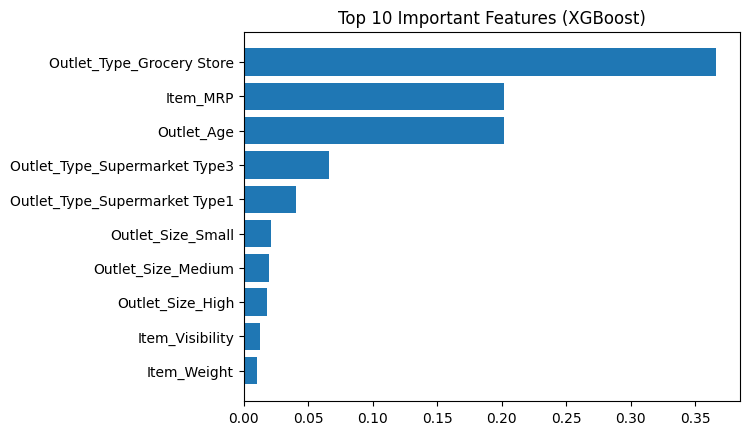

In [115]:
importance = best_xgb.feature_importances_
features = X_train_final.columns
idx = np.argsort(importance)[-10:]
plt.figure()
plt.barh(range(len(idx)), importance[idx])
plt.yticks(range(len(idx)), [features[i] for i in idx])
plt.title("Top 10 Important Features (XGBoost)")
plt.show()

8.10. Compare actual and predicted values

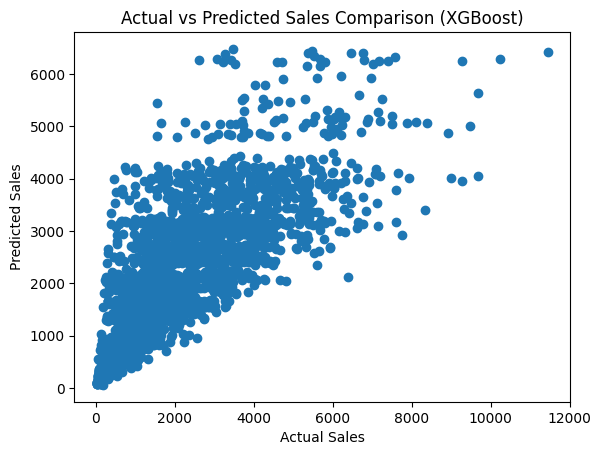

In [116]:
y_pred_xgb = best_xgb.predict(X_test_final)
plt.figure()
plt.scatter(y_test, y_pred_xgb)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales Comparison (XGBoost)")
plt.show()